### Logistic Regression

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 



In [4]:
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
df = pd.read_csv('Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
data = df[df.duplicated()]
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


In [7]:
df['age'] = df['age'] // 365

<Axes: >

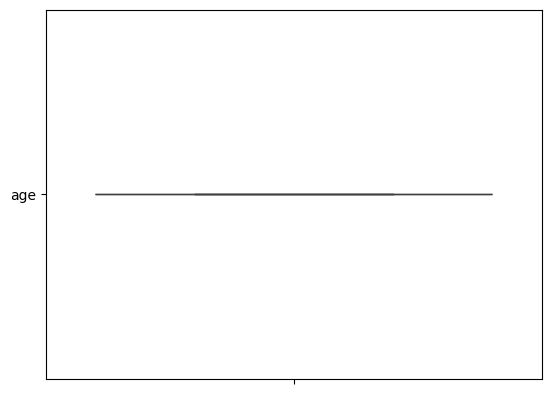

In [8]:
sns.boxplot('age')

<Axes: ylabel='Count'>

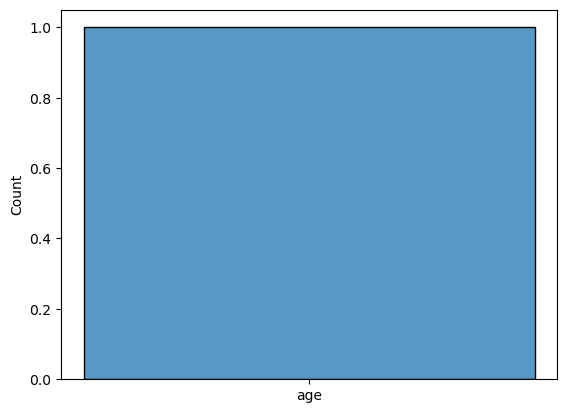

In [9]:
sns.histplot('age')

In [10]:
df['age'].unique()

array([50, 55, 51, 48, 47, 60, 61, 54, 40, 39, 45, 58, 59, 63, 64, 53, 49,
       57, 56, 46, 43, 62, 52, 42, 44, 41, 29, 30], dtype=int64)

In [11]:
df['gender'].unique()

array([2, 1], dtype=int64)

In [12]:
data = df[(df['height'].between(150,200)) & (df['weight'].between (45,120)) &(df['ap_hi'].between (100,200)) &(df['ap_lo'].between (50,90))]

<Axes: >

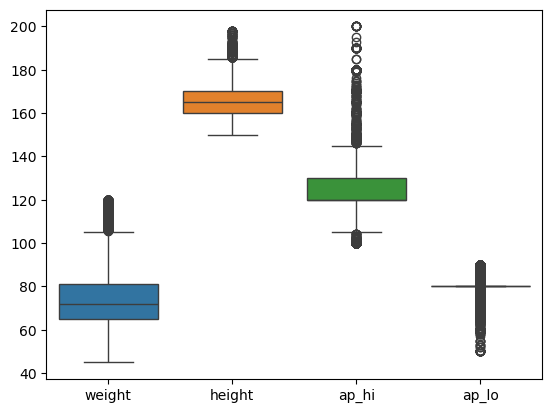

In [13]:
sns.boxplot(data=data[['weight', 'height', 'ap_hi','ap_lo']])

In [14]:
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,99992,57,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [15]:
data = data.drop( columns = 'id')

In [16]:
data.corr()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.026796,-0.081190,0.060249,0.206157,0.149013,0.149866,0.095122,-0.049144,-0.031378,-0.011903,0.242939
gender,-0.026796,1.000000,0.514697,0.150005,0.046568,0.052281,-0.040553,-0.025325,0.337123,0.166348,0.006947,-0.003164
height,-0.081190,0.514697,1.000000,0.298474,0.008691,0.031638,-0.057844,-0.025496,0.191687,0.093422,-0.008459,-0.019166
weight,0.060249,0.150005,0.298474,1.000000,0.227661,0.200668,0.134777,0.093880,0.065472,0.061306,-0.015596,0.162259
ap_hi,0.206157,0.046568,0.008691,0.227661,1.000000,0.613052,0.181767,0.083907,0.023804,0.021605,-0.001012,0.412470
ap_lo,0.149013,0.052281,0.031638,0.200668,0.613052,1.000000,0.134105,0.058374,0.016908,0.021753,-0.001082,0.292182
cholesterol,0.149866,-0.040553,-0.057844,0.134777,0.181767,0.134105,1.000000,0.452842,0.008251,0.026303,0.006909,0.221414
gluc,0.095122,-0.025325,-0.025496,0.093880,0.083907,0.058374,0.452842,1.000000,-0.006882,0.004160,-0.008490,0.086792
smoke,-0.049144,0.337123,0.191687,0.065472,0.023804,0.016908,0.008251,-0.006882,1.000000,0.346050,0.027910,-0.022810
alco,-0.031378,0.166348,0.093422,0.061306,0.021605,0.021753,0.026303,0.004160,0.346050,1.000000,0.025722,-0.019356


<Axes: >

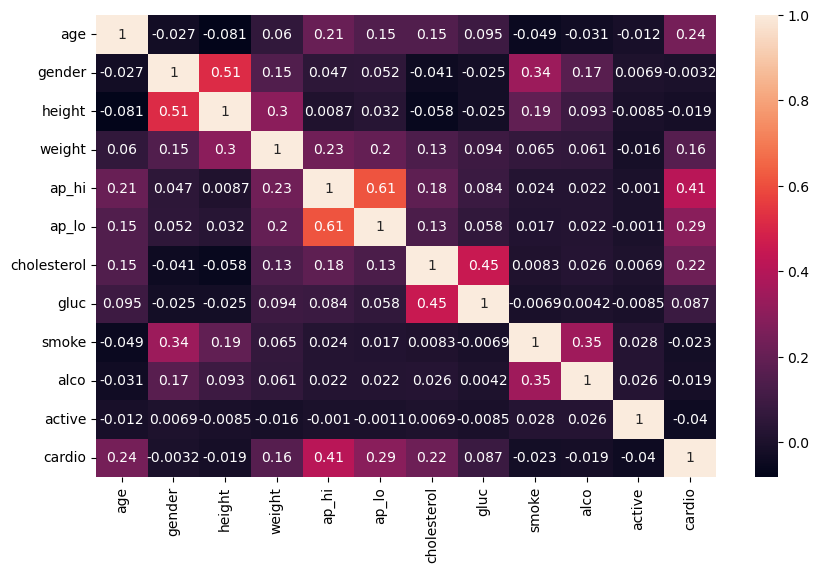

In [17]:
cor = data.corr()
plt.figure(figsize = (10,6))
sns.heatmap(cor, annot = True)

In [18]:
data.columns


Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [19]:
feature = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active'] 
target = 'cardio'

In [20]:
X= data[feature]
Y= data[target]

In [21]:
X_train, X_test,Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state= 42, stratify = Y
    

)

In [22]:
scaler = StandardScaler()

In [23]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [24]:

X_train_scale

array([[-1.14488704, -0.73877222, -0.11807192, ..., -0.31107263,
        -0.23379046,  0.49534993],
       [-0.25784356, -0.73877222,  0.01799487, ..., -0.31107263,
        -0.23379046,  0.49534993],
       [-1.4405682 ,  1.35359718, -0.66233911, ...,  3.21468335,
        -0.23379046,  0.49534993],
       ...,
       [-1.4405682 ,  1.35359718,  0.42619526, ..., -0.31107263,
        -0.23379046,  0.49534993],
       [-1.14488704, -0.73877222,  0.42619526, ..., -0.31107263,
        -0.23379046,  0.49534993],
       [ 0.18567817, -0.73877222,  0.29012847, ..., -0.31107263,
        -0.23379046,  0.49534993]])

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    random_state=42
)

In [26]:
model.fit(X_train_scale, Y_train)

LogisticRegression(class_weight='balanced', random_state=42, solver='saga')

In [27]:
Y_pred = model.predict(X_test_scale)

In [28]:


cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)


In [29]:
print(cr)

              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6418
           1       0.71      0.67      0.69      5724

    accuracy                           0.72     12142
   macro avg       0.72      0.71      0.71     12142
weighted avg       0.72      0.72      0.72     12142



In [30]:
print(cm)

[[4895 1523]
 [1916 3808]]


### Formula & Working of metrices

In [32]:
#macro_avg = precision1*precision2 / number_of_classes
ma_pr=(0.72+0.71)/2
ma_pr

0.715

In [33]:
ma_r = (0.76+0.67)/2
ma_r

0.7150000000000001

In [34]:
#wa_p = ((pv1 * support1) + (pv2 * support))/total_support
wa_p= ((0.72 * 6418) + (0.71 * 5724))/ 12142
wa_p

0.7152857848789327

In [35]:
wa_r=((0.76 * 6418) + (0.67 * 5724))/ 12142
wa_r

0.7175720639103937

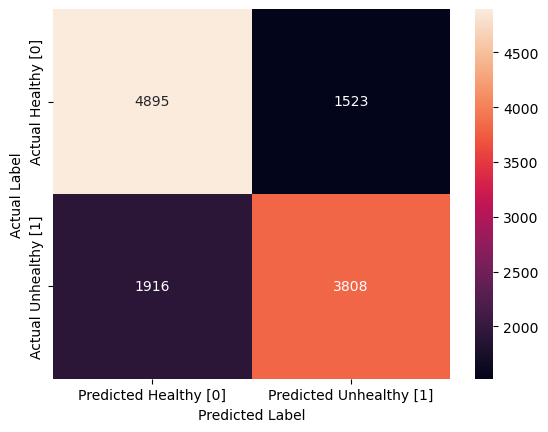

In [36]:

sns.heatmap(
    cm,
    annot=True,
    fmt='.0f',
    xticklabels=['Predicted Healthy [0]', 'Predicted Unhealthy [1]'],
    yticklabels=['Actual Healthy [0]', 'Actual Unhealthy [1]']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [37]:
data = df[(df['height'].between(150,200)) & (df['weight'].between (45,120)) &(df['ap_hi'].between (100,200)) &(df['ap_lo'].between (60,90)) ]

<Axes: >

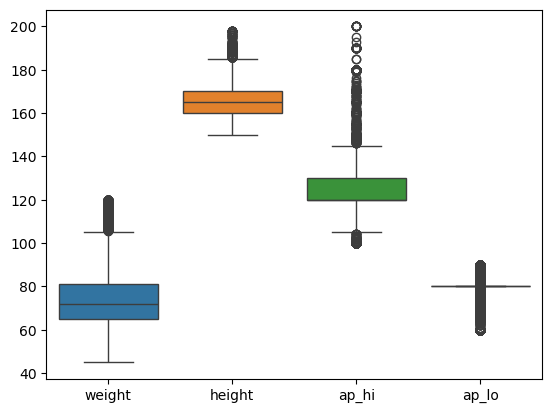

In [38]:
sns.boxplot(data=data[['weight', 'height', 'ap_hi','ap_lo']])

In [39]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,61,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [40]:
data = {'age':[40,30,50],
        
'gender':[1,2,2],
'height':[160, 155,170],
'weight':[50,60,77],
'ap_hi':[120,170,130],
'ap_lo':[60,80,80],
'cholesterol':[1,1,3],  
'gluc':[1,1,1],
'smoke':[0,1,1],
'alco':[1,1,0],
'active':[1,1,0]
}
X_data = pd.DataFrame(data)

In [41]:
X_data_scale = scaler.transform(X_data)
Y_new_pred = model.predict(X_data_scale)

In [42]:
X_data['predicted_cardio']=Y_new_pred
X_data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,predicted_cardio
0,40,1,160,50,120,60,1,1,0,1,1,0
1,30,2,155,60,170,80,1,1,1,1,1,1
2,50,2,170,77,130,80,3,1,1,0,0,1
